In [7]:
import pandas as pd
df= pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")
print(df.head())
print(df.shape)
print(df["species"].unique())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str


#el unique sirve para devolver los valores distintos de una columna

#VAMOS A SEPARAR LOS DATOS EN X (ENTRADA)  Y EN Y (LO QUE QUEREMOS PREDECIR)

In [8]:
X= df.drop(columns=["species"])
Y = df["species"]
print(X.shape)
print(Y.shape)

(150, 4)
(150,)


#DATOS DE ENTRENAMIENTO  Y TEST

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
X_train, X_test , Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
modelo= DecisionTreeClassifier(random_state=42)
modelo.fit(X_train,Y_train)
print("Modelo entrenado")

(120, 4)
(30, 4)
Modelo entrenado


#la semilla se fija, por convención en 42 sirve para que siempre elija igual cuando tenga que desempatar entre dos opciones buenas(tener el mismo arbol cada ejec)

In [52]:
from sklearn.metrics import accuracy_score
predicciones = modelo.predict(X_test)
print(predicciones)
precision = accuracy_score(Y_test,predicciones)
precision2= modelo.score(X_test,Y_test)
print(precision2)
print(f"Precision del modelo: {precision}")

['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'setosa' 'versicolor' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa']
1.0
Precision del modelo: 1.0


#VISUALIZAR EL ÁRBOL Y LAS PREGUNTAS GENERADAS DURANTE EL ENTRENAMIENTO

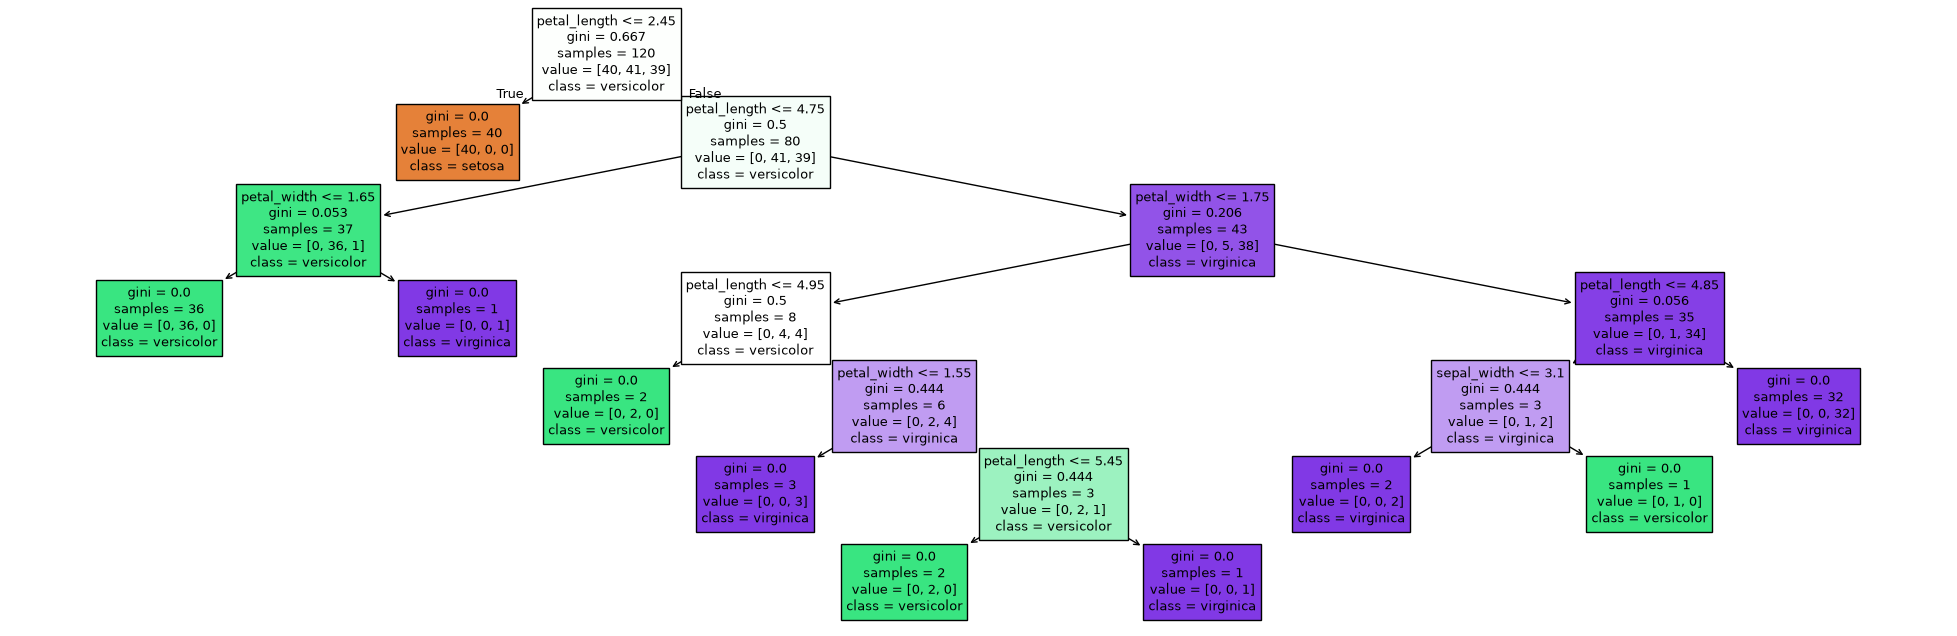

In [53]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25,8))
plot_tree(modelo, feature_names=X.columns, class_names=["setosa", "versicolor", "virginica"], filled=True)
plt.show()